## Exercise 4
### Hydrogen Burning

In [62]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt

For an easy access to the cross sections we import another package. With this package it is possible to read reaclib files and to get the cross sections at a specific temperature.  

In [63]:
from class_files.reaclib_class import reaclib

# For this, we have to give the path of the Reaclib file
r = reaclib("hburning_reactions.dat")
r.read_reaclib()

Reading line 705         


In [64]:
# With the class we can now access all reactions that are contained in the Reaclib
# For this we have to call the function "get_rate_at_temp", followed by the temperature in GK, 
# the reactants as a list, and the products as a list. The return value will be Avogadros number (NA)
# times the cross section at the given temperature.
# For example, we can access <ov>_pp * NA at 0.015 GK by:
NA_sigma_pp = r.get_rate_at_temp(0.015,["p","p"],["d"])

In [4]:
# Run winnet
! /home/teaching/WinNet/bin/winnet Hydrogen_burning.par >OUT 2>ERR

#### 1.  After your calculation, plot the generated energy (in erg/g/s) vs time (in yrs)

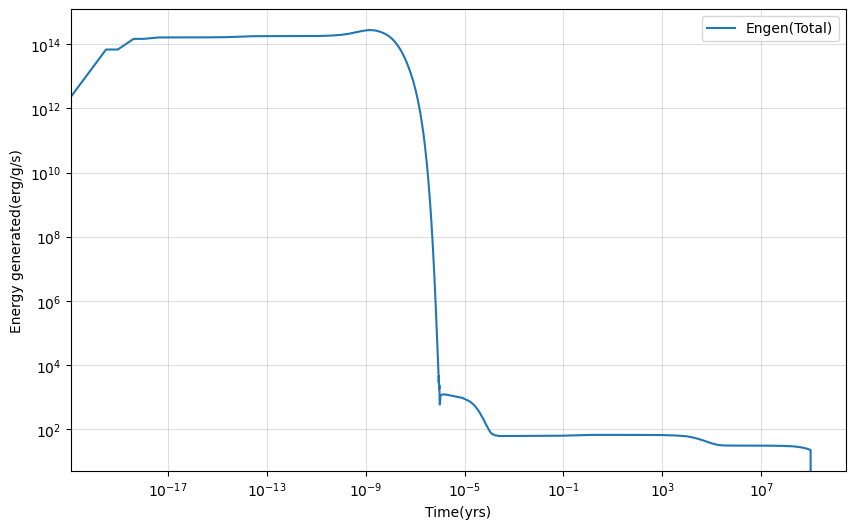

In [72]:
#Plot the generated energy vs time

fig, ax = plt.subplots(figsize=(10, 6))

#Read the file

t, E_T, S_src, E_weak, E_ng, E_pg, E_ag, E_np, E_na, E_pa, E_fiss=np.loadtxt("generated_energy.dat",unpack=True)

#First, convert time to years

t=t/(60*60*24*365.25)

#Plot the different energies

ax.plot(t,E_T,label="Engen(Total)")
#ax.plot(t,S_src,label="S_src")
#ax.plot(t,E_weak,label="Engen(weak)")
#ax.plot(t,E_ng,label="Engen(n,g)")
#ax.plot(t,E_pg,label="Engen(p,g)")
#ax.plot(t,E_ag,label="Engen(a,g)")
#ax.plot(t,E_np,label="Engen(n,p)")
#ax.plot(t,E_na,label="Engen(n,a)")
#ax.plot(t,E_pa,label="Engen(p,a)")
#ax.plot(t,E_fiss,label="Engen(fiss)")



ax.set_ylabel("Energy generated(erg/g/s)")
ax.set_xlabel("Time(yrs)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
ax.grid(alpha=0.4)

plt.show()

#### What do you observe?

The generated energy increases until the first seconds (3,1536e-10 seconds), then it maintains an almost costant value, and then anfter almost 10^-9 years it drops significantly and starts slowly decrasing.

#### 2. Plot the abundance ratio of deuterium over hydrogen vs time (in yrs)

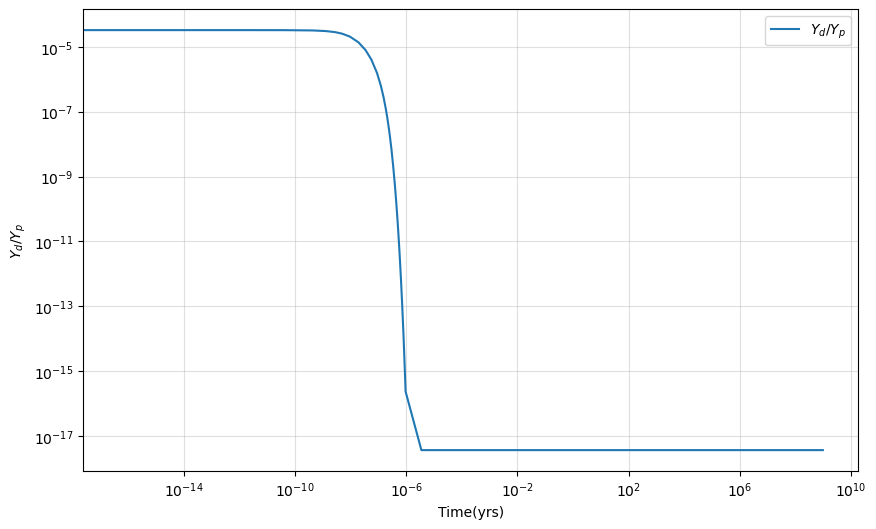

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))

#Read the file

t, Yp, Yd, Yhe3, Yhe4 = np.loadtxt("tracked_nuclei.dat",unpack=True)
#Convert time to years

t=t/(60*60*24*365.25)

#Obtain the ratio

dpratio=Yd / Yp


ax.plot(t,dpratio,label=r"$Y_d / Y_p$")

ax.set_ylabel(r"$Y_d / Y_p$")
ax.set_xlabel("Time(yrs)")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
ax.grid(alpha=0.4)

plt.show()

#### Estimate an equilibrium abundance ratio from the nuclear reaction network equations, include this ratio into your previous figure.

8.104710278365027e-20
0.011189587220289314
Equilibrium Y(d)/Y(p) = 3.621541223464128e-18


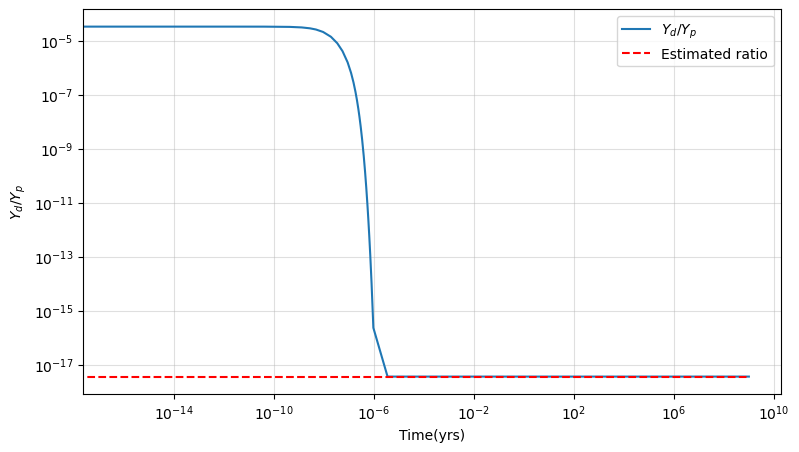

In [67]:
#Estimate an equilibrium abundance ratio from the nuclear reaction network equations
#To obtain the reaction rates, use the provided class file as shown in the Jupyter notebook.
NA_sigma_pp = r.get_rate_at_temp(0.015,["p","p"],["d"])
NA_sigma_dp = r.get_rate_at_temp(0.015,["d","p"],["he3"])

print(NA_sigma_pp)
print(NA_sigma_dp)

#Equilibrium ratio calculation from the formula
#Y(d)/Y(p)eq = NA<σv>_pp / (2 * NA<σv>_dp)

dpratio_eq = NA_sigma_pp / (2.0 * NA_sigma_dp)
print("Equilibrium Y(d)/Y(p) =", ratio_eq)

plt.figure(figsize=(9,5))

plt.plot(t,dpratio,label=r"$Y_d / Y_p$")
plt.hlines(dpratio_eq,xmin=t.min(), xmax=t.max(),linestyles='--',color='red',label="Estimated ratio")

plt.ylabel(r"$Y_d / Y_p$")
plt.xlabel("Time(yrs)")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.4)

plt.show()

#### How long does it take to reach equilibrium? Is it a comparable timescale to the lifetime of the star? Can you identify signatures of deuterium burning in the figure of the energy generation? Given your finding, do you think it is possible to measure primordial deuterium abundances?

The tame that takes the deuterium to proton ratio to reach equilibrium is long compared to typical stellar evolutionary timescales. That timescale is comparable or bigger to the the lifetime of the star only for low and intermediate mass star since those kinds of stars can live for trillions of years. 

One can easily see that the curve of the deuterium to proton ratio is shaped very similarly to the curve that the total energy describes in section 1. With this and looking again at the graph of this section, one can think that the measurement of the primordial deuterium abundances is possible, since the deuterium abundances are expected to stay more like constant.

#### 3. Now repeat the plot but for the abundance ratio of 3He over hydrogen.
   

8.104710278365027e-20
2.219153470296946e-10
1.3513258373395284e-05


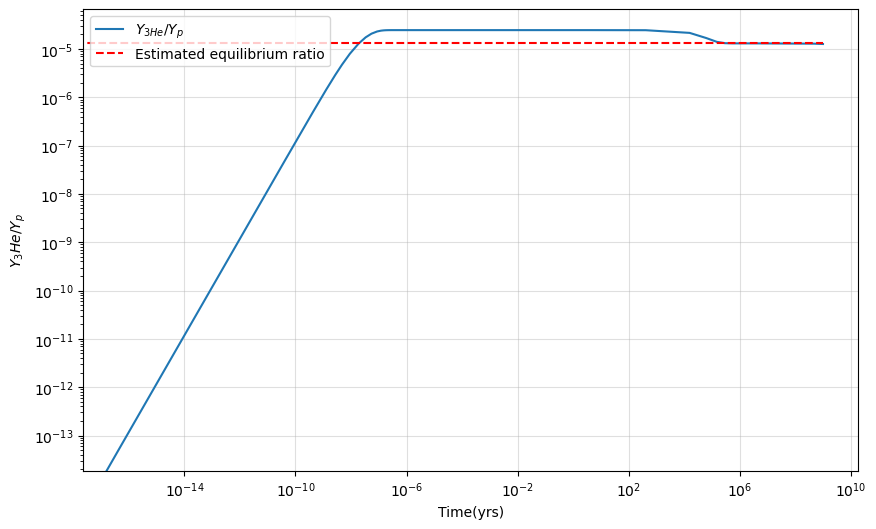

In [70]:
#We already have the abundances from He3 and He4 from the previous section.
#We calculate the ratio:
he3pratio= Yhe3/Yp

#To obtain the reaction rates:
NA_sigma_pp = r.get_rate_at_temp(0.015,["p","p"],["d"])
NA_sigma_he3he3 = r.get_rate_at_temp(0.015, ["he3", "he3"], ["p", "p", "he4"])

print(NA_sigma_pp)
print(NA_sigma_he3he3)

#The equilibrium abundance assuming the pp-I chain is given by
#Y(3he)/Y(p)_eq = sqrt(NA<σv>_pp / (2 * NA<σv>_3he3he))

he3pratio_eq =  np.sqrt(NA_sigma_pp/(2*NA_sigma_he3he3))

print(he3pratio_eq)

#Now we plot the ratio vs time
plt.figure(figsize=(10,6))

plt.plot(t,he3pratio,label=r"$Y_{3He} / Y_p$")
plt.hlines(he3pratio_eq,xmin=t.min(), xmax=t.max(),linestyles='--',color='red',label="Estimated equilibrium ratio")

plt.ylabel(r"$Y_3He / Y_p$")
plt.xlabel("Time(yrs)")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.4)

plt.show()

#### How long does it take for 3He to achieve an equilibrium? Do you have an explanation why the 3He/p abundance ratio goes first above its equilibrium value? Can you identify the point in time in the energy generation figure?

The curve of the 3He increases linearly until it meets the equilibrium value at 10^-6 approximately. It surpasses the value and maintains an almost costant value greater than the equilibrium until it achieves the expected value at almost 10^6 years (one million).
If we consider "achieving equilibrium" when the curve meets the horizontal line the first time, then the 3He/p abundance ratio reaches equilibrium very quickly compared to stellar timescales.

The reason for the behavior of the curve rising above the equilibrium could be explained thinking that this process is dominated by the reaction $d(p,\gamma)^4\text{He}$ which produces 3He and is very very fast, but the destruction of 3He takes part in the reaction ${}^{3}\text{He}({}^{3}\text{He}, 2p){}^4\text{He}$ and that reaction is significantly slower.

If we examinate the plot of the energy generation vs time we can see that the line 10^6 would correspond to the second time that the energy curve rises, right after the great fall, just before falling again and having almost a constant value.

#### 4. Calculate the energy generation of the hydrogen burning assuming that deuterium and 3He are in equilibrium.Furthermore, assume that hydrogen is constant and has an abundance of 0.751.

7.188193726456571e-17
69.35405051286753


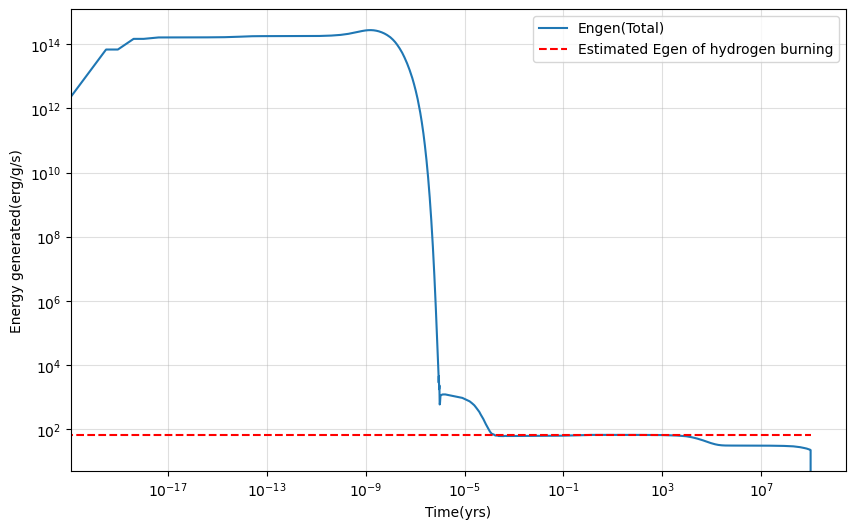

In [73]:
#We already have the values for the equilibrium of 3He and deuterium to proton ratio.
#We also have the values of the avogadro number times each cross section.
#We set hydrogen at 0.751
Yp_eq=0.751

#Now we can obtain the abundances of 3He and d:
Yhe3_eq = he3pratio_eq/Yp_eq
Yd_eq = dpratio_eq/Yp_eq

#The energy generation in [MeV/baryon/s] can be in this case calculated by:
#E_ppI=0.5*rhoYp^2 *NA<σv>_pp*Q_pp + 0.5*rhoY3He^2 *NA<σv>_3he3he*Q_3he3he + rhoYdYp*NA<σv>_dp*Q_dp
#We set the Q-values and density
Q_pp = 1.44
Q_dp = 5.49
Q_3he3he = 12.9 
rho = 100.0

#We now calculate the energy production
E_ppI= 0.5*rho*(Yp_eq**2)*NA_sigma_pp*Q_pp + 0.5*rho*(Yhe3_eq**2)*NA_sigma_he3he3*Q_3he3he + rho*Yd_eq*Yp_eq*NA_sigma_dp*Q_dp
print(E_ppI)

#But the plot from section 1 has the energy in erg/g/s, so whe have to change the units of our expected value.
# 1Mev=1.60218e-6 and the number of baryons per gram is the avogadro number Na
E_ppI=E_ppI*1.60218e-6*6.022e23
print(E_ppI)

#Now we plot the figure from section 1 with the horizontal line

plt.figure(figsize=(10,6))

plt.plot(t,E_T,label="Engen(Total)")
plt.hlines(E_ppI,xmin=t.min(),xmax=t.max(),linestyles='--',color="red",label="Estimated Egen of hydrogen burning")

plt.ylabel("Energy generated(erg/g/s)")
plt.xlabel("Time(yrs)")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.4)

plt.show()


#### Can you reproduce the energy that WinNet calculates?

After the first irregular phases, the energy settles to an almost costant value very close to $10^2$, that curve fits perfectly with the horizontal line, and it also makes sense since the calculated value of the energy generation of the hydrogen burning (printed before the graph) $E_{pp-I}=69.35405051286753$

Then we can conclude that we can reproduce well the calculations of WinNet

#### 5. Now increase the temperature to T=0.05GK, calculate the energy generation with Winnet and repeat your previous estimates for the energy generation.

In [ ]:
# Run winnet
! /home/teaching/WinNet/bin/winnet Hydrogen_burning.par >OUT 2>ERR

8.104710278365027e-20
0.011189587220289314
2.219153470296946e-10
Equilibrium Y(d)/Y(p) = 3.621541223464128e-18
Equilibrium Y(3He)/Y(p) = 1.3513258373395284e-05
69.35405051286753


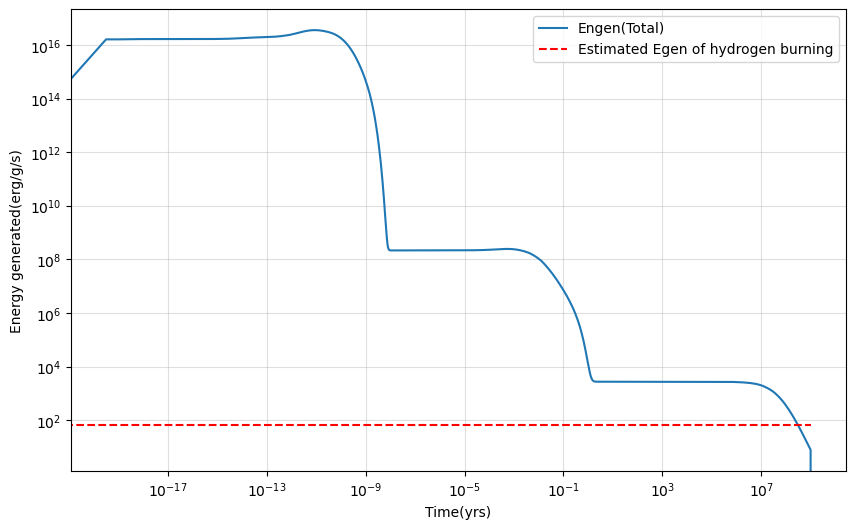

In [ ]:
#Firstly, we read our generated_energy.dat file again and we obtain the energy (converting time to years):
t, E_T, S_src, E_weak, E_ng, E_pg, E_ag, E_np, E_na, E_pa, E_fiss=np.loadtxt("generated_energy.dat",unpack=True)
t=t/(60*60*24*365.25)

#We have to obtain again the cross sections:
NA_sigma_pp = r.get_rate_at_temp(0.015,["p","p"],["d"])
NA_sigma_dp = r.get_rate_at_temp(0.015,["d","p"],["he3"])
NA_sigma_he3he3 = r.get_rate_at_temp(0.015, ["he3", "he3"], ["p", "p", "he4"])

print(NA_sigma_pp)
print(NA_sigma_dp)
print(NA_sigma_he3he3)

#We also need to calculate again the 3He and deuterium to proton ratios of and their abundances:
he3pratio_eq =  np.sqrt(NA_sigma_pp/(2*NA_sigma_he3he3))
dpratio_eq = NA_sigma_pp / (2.0 * NA_sigma_dp)
print("Equilibrium Y(d)/Y(p) =", ratio_eq)
print("Equilibrium Y(3He)/Y(p) =",he3pratio_eq)
#We set hydrogen at 0.751
Yp_eq=0.751
Yhe3_eq = he3pratio_eq/Yp_eq
Yd_eq = dpratio_eq/Yp_eq

#We set the Q-values and density:
Q_pp = 1.44
Q_dp = 5.49
Q_3he3he = 12.9 
rho = 100.0

#And now we calculate again the energy generation of the hydrogen burning (And convert to manageable units):
E_ppI= 0.5*rho*(Yp_eq**2)*NA_sigma_pp*Q_pp + 0.5*rho*(Yhe3_eq**2)*NA_sigma_he3he3*Q_3he3he + rho*Yd_eq*Yp_eq*NA_sigma_dp*Q_dp*1.60218e-6*6.022e23
E_ppI=E_ppI
print(E_ppI)

#Finally, we plot our figure and the expected value:
plt.figure(figsize=(10,6))

plt.plot(t,E_T,label="Engen(Total)")
plt.hlines(E_ppI,xmin=t.min(),xmax=t.max(),linestyles='--',color="red",label="Estimated Egen of hydrogen burning")

plt.ylabel("Energy generated(erg/g/s)")
plt.xlabel("Time(yrs)")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.4)

plt.show()

#### Can you still reproduce the energy generation of WinNet, if not what could be the reason?

We see in the graph that the new costant value that the curve reaches is approximately $10^3$ to $10^4\,\text{erg/g/s}$. And it is different from our original estimated value of $E_{pp-I}=69.35405051286753$.
We no longer can reproduce the calculations from WinNet.

We know that reactions in the pp-I chain are strongly dependent on temperature, so modifying the remperature can cause a propagation chain of differences with the previous calculations of WinNet.